In [ ]:
!pip install qiskit qiskit-ibm-runtime qiskit-algorithms pylatexenc qiskit-aer
!pip install pandas scikit-learn matplotlib seaborn rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 6.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=279eff410fffb25816400b1b8da6b91b74e61c5b0d1f1178b0ea757187c5715d
  Stored in 

In [ ]:
import numpy as np
import pandas as pd
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from rdkit.Chem import AllChem

# Qiskit Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---

EN_MAP = {'H': 2.20, 'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55,
          'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}

# α as named global constant
ALPHA    = 0.1

N_QUBITS = 12
SHOTS    = 1024
N_SPLITS = 10
N_SUB    = 125    # Samples per class (250 total per dataset)

# All 8 MoleculeNet datasets
DATASETS = {
    'BBBP':          {"url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv",
                      "smiles": "smiles",  "target": "p_np",                              "type": "clf"},
    'Tox21':         {"url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz",
                      "smiles": "smiles",  "target": "NR-AR",                             "type": "clf"},
    'BACE':          {"url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/bace.csv",
                      "smiles": "mol",     "target": "Class",                             "type": "clf"},
    'HIV':           {"url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv",
                      "smiles": "smiles",  "target": "HIV_active",                        "type": "clf"},
    'ClinTox':       {"url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/clintox.csv.gz",
                      "smiles": "smiles",  "target": "FDA_APPROVED",                      "type": "clf"},
    'ESOL':          {"url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv",
                      "smiles": "smiles",  "target": "measured log solubility in mols per litre", "type": "reg"},
    'Lipophilicity': {"url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv",
                      "smiles": "smiles",  "target": "exp",                               "type": "reg"},
    'FreeSolv':      {"url": "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/SAMPL.csv",
                      "smiles": "smiles",  "target": "expt",                              "type": "reg"}
}

# --- 2. CORE FUNCTIONS ---
def qmse_hero_normal(smiles):
    """
    Standard QMSE 10+2 feature map

    """
    mol = Chem.MolFromSmiles(smiles)
    qc  = QuantumCircuit(N_QUBITS)
    if not mol:
        return qc

    atoms        = list(mol.GetAtoms())
    backbone     = atoms[:10]
    tail         = atoms[10:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    # Stage 1: Backbone encoding — θᵢ = α · χᵢ²
    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry(ALPHA * (en ** 2), mol_to_qubit[atom.GetIdx()])

    # Stage 2: Tail summary encoding — θ = (α/2) · Σχ, alternating split
    if tail:
        tail_A, tail_B = tail[0::2], tail[1::2]
        if tail_A:
            qc.ry((ALPHA / 2) * sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in tail_A), 10)
        if tail_B:
            qc.ry((ALPHA / 2) * sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in tail_B), 11)

    # Stage 3: Topological entanglement — ϕᵢⱼ = wᵢⱼ/2 for ALL bonds
    # phi_ij computed once and applied uniformly to all three bond cases
    for bond in mol.GetBonds():
        idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        q1, q2     = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)
        phi_ij     = bond.GetBondTypeAsDouble() / 2

        if q1 is not None and q2 is not None:
            qc.rxx(phi_ij, q1, q2)
        elif q1 is not None:
            qc.rxx(phi_ij, q1, 10)
            qc.rxx(phi_ij, q1, 11)
        elif q2 is not None:
            qc.rxx(phi_ij, q2, 10)
            qc.rxx(phi_ij, q2, 11)

    qc.measure_all()
    return qc


def extract_features(pub_result, n_qubits=12):
    counts = pub_result.data.meas.get_counts()
    p      = np.zeros(2 ** n_qubits)
    tot    = sum(counts.values())
    for k, v in counts.items():
        idx = int(k, 2) if isinstance(k, str) else k
        # bounds check prevents crash on out-of-range index
        if idx < len(p):
            p[idx] = v / tot
    return p


def run_hardware_job(hw_sampler, isa_circuits, shots, max_retries=3):

    for attempt in range(max_retries):
        try:
            hw_job = hw_sampler.run([(c,) for c in isa_circuits], shots=shots)
            print(f"  Hardware Job Submitted: {hw_job.job_id()}")
            result = hw_job.result()
            return result
        except Exception as e:
            print(f"  Attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                print(f"  Waiting 60 seconds before retry...")
                time.sleep(60)
            else:
                print(f"  All {max_retries} attempts failed. Skipping hardware for this dataset.")
                return None


# --- 3. HARDWARE SETUP ---
print("Connecting to IBM Quantum...")
token    = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(
        token=token, channel="ibm_cloud",
        instance=instance, name="Name", overwrite=True
    )
except:
    pass

service    = QiskitRuntimeService(name="Name")
hw_backend = service.backend("ibm_kingston")
print(f"Target Backend: {hw_backend.name}")

# seed_transpiler=42 — pins physical qubit routing for reproducibility
pm         = generate_preset_pass_manager(
    backend=hw_backend, optimization_level=1, seed_transpiler=42
)
aer_sampler = AerSampler()
hw_sampler  = RuntimeSampler(mode=hw_backend)

# --- 4. MAIN BENCHMARKING LOOP ---
master_results = []

# (critical): Load any previously saved results so a crash never loses
# completed datasets — resume from where you left off
RESULTS_CSV = "master_benchmark_results.csv"
try:
    existing = pd.read_csv(RESULTS_CSV)
    master_results = existing.to_dict('records')
    completed_datasets = set(existing['Dataset'].unique())
    print(f"Resuming — already completed: {completed_datasets}")
except FileNotFoundError:
    completed_datasets = set()
    print("Starting fresh benchmark run.")

for ds_name, config in DATASETS.items():

    # Skip datasets already completed in a previous run
    if ds_name in completed_datasets:
        print(f"\nSkipping {ds_name} — already in results file.")
        continue

    print(f"\n{'='*60}\nPROCESSING DATASET: {ds_name}\n{'='*60}")

    # --- Load and clean ---
    try:
        df = pd.read_csv(config["url"]).dropna(subset=[config["target"], config["smiles"]])
    except Exception as e:
        print(f"Failed to load {ds_name}: {e}. Skipping.")
        continue

    df = df[df[config["smiles"]].apply(
        lambda s: Chem.MolFromSmiles(s) is not None and len(s) < 70
    )]

    # Binarize regression targets at median (Section D)
    if config["type"] == "reg":
        median_val          = df[config["target"]].median()
        df['binary_target'] = (df[config["target"]] >= median_val).astype(int)
    else:
        df['binary_target'] = df[config["target"]].astype(int)

    # Balance dataset — 125 pos + 125 neg (Section D)
    df_pos = df[df['binary_target'] == 1]
    df_neg = df[df['binary_target'] == 0]

    if len(df_pos) < N_SUB or len(df_neg) < N_SUB:
        print(f"Skipping {ds_name}: insufficient samples for balanced 250-molecule benchmark.")
        continue

    df_final    = pd.concat([
        df_pos.sample(N_SUB, random_state=42),
        df_neg.sample(N_SUB, random_state=42)
    ]).sample(frac=1, random_state=42)

    y           = df_final['binary_target'].values
    smiles_list = df_final[config["smiles"]].values

    # --- Build circuits ---
    print(f"Generating 10+2 QMSE circuits for {ds_name}...")
    circuits = [qmse_hero_normal(s) for s in smiles_list]

    # --- Simulator features ---
    print("Running on Simulator...")
    X_sim = np.array([
        extract_features(p)
        for p in aer_sampler.run([(c,) for c in circuits], shots=SHOTS).result()
    ])

    # --- Hardware features (with retry) ---
    print(f"Running on Hardware ({hw_backend.name})...")
    isa_circuits = pm.run(circuits)
    hw_result    = run_hardware_job(hw_sampler, isa_circuits, SHOTS)

    if hw_result is None:
        # Hardware failed after all retries — record NaN for hardware metrics
        # so the dataset is not lost entirely from the results
        X_hw         = None
        hw_available = False
        print(f"  Hardware unavailable for {ds_name} — recording NaN for hardware metrics.")
    else:
        X_hw         = np.array([extract_features(pub) for pub in hw_result])
        hw_available = True

    # --- Classical features (ECFP4) ---
    X_class = np.array([
        np.array(AllChem.GetMorganFingerprintAsBitVect(
            Chem.MolFromSmiles(s), 2, nBits=256
        ))
        for s in smiles_list
    ])

    # --- 10-Split cross-validation ---
    print(f"Evaluating models across {N_SPLITS} splits...")
    sss = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)

    for i, (train_idx, test_idx) in enumerate(sss.split(X_class, y)):
        y_test = y[test_idx]

        # Classical — Random Forest
        clf_c    = RandomForestClassifier(n_estimators=100).fit(X_class[train_idx], y[train_idx])
        y_pred_c = clf_c.predict(X_class[test_idx])
        y_prob_c = clf_c.predict_proba(X_class[test_idx])[:, 1]
        master_results.append({
            'Dataset': ds_name, 'Method': 'Classical (RF)', 'Split': i,
            'Accuracy':  accuracy_score(y_test, y_pred_c),
            'Precision': precision_score(y_test, y_pred_c, zero_division=0),
            'Recall':    recall_score(y_test, y_pred_c, zero_division=0),
            'F1-Score':  f1_score(y_test, y_pred_c, zero_division=0),
            'AUC-ROC':   roc_auc_score(y_test, y_prob_c)
        })

        # Quantum Simulator — SVM RBF
        sc_s     = StandardScaler()
        clf_s    = SVC(kernel='rbf', C=10, probability=True).fit(
            sc_s.fit_transform(X_sim[train_idx]), y[train_idx]
        )
        X_sim_t  = sc_s.transform(X_sim[test_idx])
        y_pred_s = clf_s.predict(X_sim_t)
        y_prob_s = clf_s.predict_proba(X_sim_t)[:, 1]
        master_results.append({
            'Dataset': ds_name, 'Method': 'Quantum Simulator', 'Split': i,
            'Accuracy':  accuracy_score(y_test, y_pred_s),
            'Precision': precision_score(y_test, y_pred_s, zero_division=0),
            'Recall':    recall_score(y_test, y_pred_s, zero_division=0),
            'F1-Score':  f1_score(y_test, y_pred_s, zero_division=0),
            'AUC-ROC':   roc_auc_score(y_test, y_prob_s)
        })

        # Real Quantum Hardware — SVM RBF
        if hw_available:
            sc_h     = StandardScaler()
            clf_h    = SVC(kernel='rbf', C=10, probability=True).fit(
                sc_h.fit_transform(X_hw[train_idx]), y[train_idx]
            )
            X_hw_t   = sc_h.transform(X_hw[test_idx])
            y_pred_h = clf_h.predict(X_hw_t)
            y_prob_h = clf_h.predict_proba(X_hw_t)[:, 1]
            master_results.append({
                'Dataset': ds_name, 'Method': 'Quantum Hardware', 'Split': i,
                'Accuracy':  accuracy_score(y_test, y_pred_h),
                'Precision': precision_score(y_test, y_pred_h, zero_division=0),
                'Recall':    recall_score(y_test, y_pred_h, zero_division=0),
                'F1-Score':  f1_score(y_test, y_pred_h, zero_division=0),
                'AUC-ROC':   roc_auc_score(y_test, y_prob_h)
            })

    # Save incrementally after EVERY dataset
    # If the run crashes on dataset 6, datasets 1-5 are already safely on disk
    pd.DataFrame(master_results).to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV} ({ds_name} complete)")

# --- 5. TABLE  ---
df_results = pd.DataFrame(master_results)
df_results.to_csv(RESULTS_CSV, index=False)

print("\n" + "=" * 120)
print(f"{'Dataset':15} | {'Method':22} | {'Accuracy':12} | {'Precision':12} | {'Recall':12} | {'F1-Score':12} | {'AUC-ROC':12}")
print("-" * 120)
for ds in df_results['Dataset'].unique():
    for m in df_results['Method'].unique():
        subset = df_results[(df_results['Dataset'] == ds) & (df_results['Method'] == m)]
        if not subset.empty:
            acc  = f"{subset['Accuracy'].mean():.2f} ± {subset['Accuracy'].std():.2f}"
            prec = f"{subset['Precision'].mean():.2f} ± {subset['Precision'].std():.2f}"
            rec  = f"{subset['Recall'].mean():.2f} ± {subset['Recall'].std():.2f}"
            f1   = f"{subset['F1-Score'].mean():.2f} ± {subset['F1-Score'].std():.2f}"
            auc  = f"{subset['AUC-ROC'].mean():.2f} ± {subset['AUC-ROC'].std():.2f}"
            print(f"{ds:15} | {m:22} | {acc:12} | {prec:12} | {rec:12} | {f1:12} | {auc:12}")
    print("-" * 120)

Connecting to IBM Quantum...
Target Backend: ibm_kingston
Resuming — already completed: {'Tox21', 'BBBP'}

Skipping BBBP — already in results file.

Skipping Tox21 — already in results file.

PROCESSING DATASET: BACE
Generating 10+2 QMSE circuits for BACE...
Running on Simulator...
Running on Hardware (ibm_kingston)...
  Hardware Job Submitted: d6uqniov5rlc73f48pt0


Evaluating models across 10 splits...
Results saved to master_benchmark_results.csv (BACE complete)

PROCESSING DATASET: HIV


Generating 10+2 QMSE circuits for HIV...
Running on Simulator...
Running on Hardware (ibm_kingston)...
  Hardware Job Submitted: d6uqoiitnsts73esfvtg


Evaluating models across 10 splits...
Results saved to master_benchmark_results.csv (HIV complete)

PROCESSING DATASET: ClinTox


Skipping ClinTox: insufficient samples for balanced 250-molecule benchmark.

PROCESSING DATASET: ESOL
Generating 10+2 QMSE circuits for ESOL...
Running on Simulator...
Running on Hardware (ibm_kingston)...
  Hardware Job Submitted: d6uqpc469uic73ciihv0


Evaluating models across 10 splits...
Results saved to master_benchmark_results.csv (ESOL complete)

PROCESSING DATASET: Lipophilicity
Generating 10+2 QMSE circuits for Lipophilicity...
Running on Simulator...
Running on Hardware (ibm_kingston)...
  Hardware Job Submitted: d6uqq6itnsts73esg23g


Evaluating models across 10 splits...
Results saved to master_benchmark_results.csv (Lipophilicity complete)

PROCESSING DATASET: FreeSolv
Generating 10+2 QMSE circuits for FreeSolv...
Running on Simulator...
Running on Hardware (ibm_kingston)...


  Hardware Job Submitted: d6uqr0c69uic73ciik1g


Evaluating models across 10 splits...
Results saved to master_benchmark_results.csv (FreeSolv complete)

Dataset         | Method                 | Accuracy     | Precision    | Recall       | F1-Score     | AUC-ROC     
------------------------------------------------------------------------------------------------------------------------
BBBP            | Classical (RF)         | 0.71 ± 0.05  | 0.71 ± 0.06  | 0.72 ± 0.10  | 0.71 ± 0.06  | 0.78 ± 0.06 
BBBP            | Quantum Simulator      | 0.76 ± 0.08  | 0.76 ± 0.10  | 0.76 ± 0.07  | 0.76 ± 0.07  | 0.81 ± 0.08 
BBBP            | Quantum Hardware       | 0.73 ± 0.09  | 0.74 ± 0.11  | 0.72 ± 0.08  | 0.73 ± 0.08  | 0.78 ± 0.09 
------------------------------------------------------------------------------------------------------------------------
Tox21           | Classical (RF)         | 0.64 ± 0.06  | 0.66 ± 0.10  | 0.62 ± 0.10  | 0.63 ± 0.06  | 0.70 ± 0.07 
Tox21           | Quantum Simulator      | 0.57 ± 0.06  | 0.56 ± 0.04  | 

Plot successfully saved as 'cross_dataset_accuracy_ieee.png'


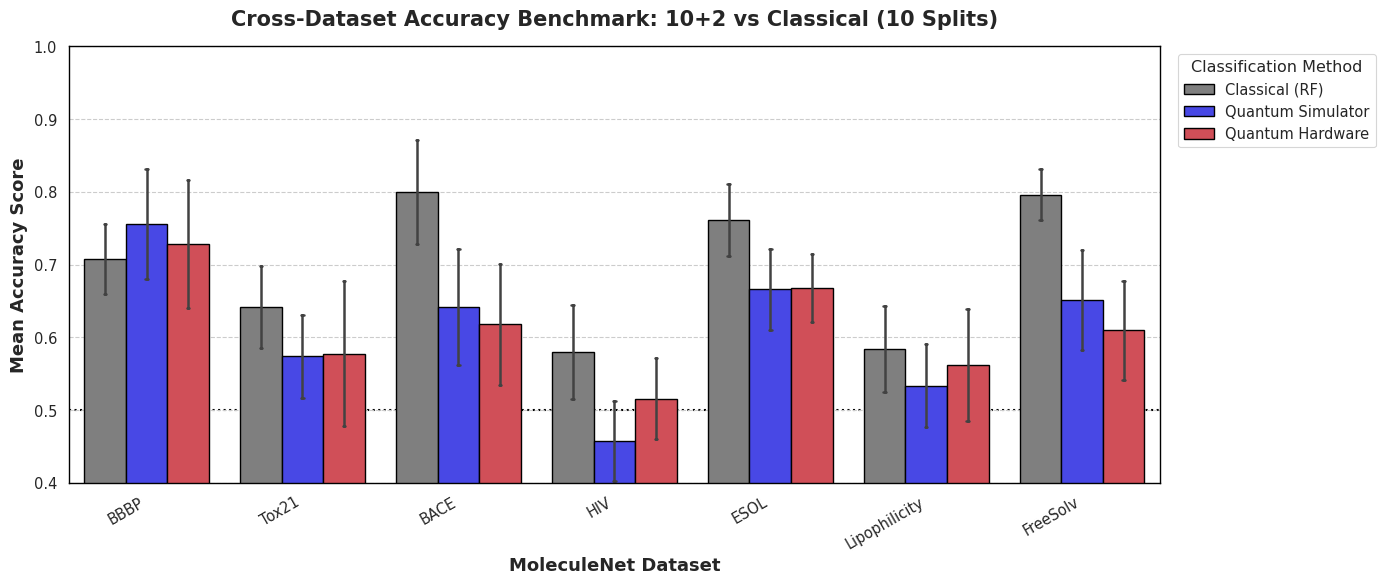

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


try:

    df = pd.read_csv(RESULTS_CSV)
except FileNotFoundError:
    print("Error: 'master_benchmark_results.csv' not found. Please run the benchmarking script first.")
    exit()


plt.figure(figsize=(14, 6))
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--', 'axes.edgecolor': 'black'})


method_palette = {
    'Classical (RF)': '#7f7f7f',
    'Quantum Simulator': '#2e2eff',
    'Quantum Hardware': '#e63946'
}


ax = sns.barplot(
    data=df,
    x='Dataset',
    y='Accuracy',
    hue='Method',
    palette=method_palette,
    edgecolor='black',
    linewidth=1,
    capsize=0.05,
    errorbar='sd'
)

# --- 3. FORMATTING & LABELS ---
plt.title('Cross-Dataset Accuracy Benchmark: 10+2 vs Classical (10 Splits)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('MoleculeNet Dataset', fontsize=13, fontweight='bold')
plt.ylabel('Mean Accuracy Score', fontsize=13, fontweight='bold')


plt.ylim(0.4, 1.0)


plt.legend(title='Classification Method', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)


plt.xticks(rotation=30, ha='right')


plt.axhline(y=0.5, color='black', linestyle=':', linewidth=1.5, zorder=0, label='Random Guessing (0.5)')

plt.tight_layout()

print("Plot successfully saved as 'cross_dataset_accuracy.png'")

plt.show()